## Clase 3 - Proyecto Práctico 1 – Utilizar Spark MLlib y el algoritmo de Regresion clasica.

###### Contexto: A partir de un dataset publico provisto por Airbnb en formato parquet, extraer el feature requerido para construir un modelo de Regresion Lineal de una variable (bedrooms) que permita predecir el precio del inmueble a rentar.

###### Dataset: El dataset contiene multiples columnas, de las cuales se requieren las columnas "bedrooms" y "price".
###### Objetivo: A partir del dataset con las observaciones de precios y numero de habitaciones, construir un modelo de Regresion Lineal clasico que permita predecir el valor del precio del inmueble en funcion de la cantidad de habitaciones.

# 1. Configuración de PySpark en Google Colab

In [ ]:
'''# Instalar Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Descargar Spark 3.5.1
!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

# Extraer los archivos de Spark
!tar xf spark-3.5.1-bin-hadoop3.tgz

# Instalar findspark para facilitar el uso de Spark en Python
!pip install -q findspark

# Configurar las variables de entorno para Java y Spark
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

# Inicializar Spark usando findspark
import findspark
findspark.init()

# Crear la sesión de Spark
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

# Verificar la versión de Spark
print(f"Versión de Spark: {spark.version}")
'''

Versión de Spark: 3.5.1


In [5]:
# Configuramos las variables de entorno para Java y Spark
import os
os.environ["HADOOP_OPTS"] = "-Djava.library.path="
os.environ["JAVA_HOME"] = "C:\\Program Files\\Java\\jdk1.8.0_202"

# Importamos la librería de apache spark
import pyspark as ps
from pyspark.sql import SparkSession # Importamos SparkSesion
from pyspark.sql.types import IntegerType, StringType, FloatType, DoubleType, DateType, TimestampType # Importamos tipos de datos
from datetime import datetime
import time

print(f'Versión de Spark: {ps.__version__}')

Versión de Spark: 3.5.4


In [2]:
# Inicializamos usando findspark
import findspark
findspark.init()

# Creamos una sesion de Spark
spark = ps.sql.SparkSession.builder \
    .appName("Grafos en Spark") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.hadoop.io.native.lib.available", "false") \
    .config("spark.hadoop.use.native.io", "false") \
    .getOrCreate()


# 2. Montamos Google Drive

In [9]:
'''from google.colab import drive
drive.mount('/content/drive')'''

"from google.colab import drive\ndrive.mount('/content/drive')"

# 3. Importamos librerías necesarias

In [3]:
from pyspark.sql.functions import col, expr, percent_rank, percentile_approx

# 4. Cargamos CSV Airbnb

In [4]:
# Definir la ruta del archivo Parquet
file_path = 'C:\\Users\\Usuario\\Desktop\\Master Ciencia de Datos\\Proyectos\\DataScienceIEBS\\Bloque 7\\Spark\\Ficheros Input Notebooks\\Clase 3\\sf-airbnb-clean.parquet'

# Leer el archivo Parquet con Spark
airbnbDF = spark.read.parquet(file_path)

# Mostrar el DataFrame (en lugar de display())
airbnbDF.show()


Py4JJavaError: An error occurred while calling o34.parquet.
: java.lang.UnsatisfiedLinkError: org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Ljava/lang/String;I)Z
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access0(Native Method)
	at org.apache.hadoop.io.nativeio.NativeIO$Windows.access(NativeIO.java:793)
	at org.apache.hadoop.fs.FileUtil.canRead(FileUtil.java:1249)
	at org.apache.hadoop.fs.FileUtil.list(FileUtil.java:1454)
	at org.apache.hadoop.fs.RawLocalFileSystem.listStatus(RawLocalFileSystem.java:601)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:1972)
	at org.apache.hadoop.fs.FileSystem.listStatus(FileSystem.java:2014)
	at org.apache.hadoop.fs.ChecksumFileSystem.listStatus(ChecksumFileSystem.java:761)
	at org.apache.spark.util.HadoopFSUtils$.listLeafFiles(HadoopFSUtils.scala:180)
	at org.apache.spark.util.HadoopFSUtils$.$anonfun$parallelListLeafFilesInternal$1(HadoopFSUtils.scala:95)
	at scala.collection.TraversableLike.$anonfun$map$1(Tr

# 5. Separamos nuestras observaciones en conjuntos de entrenamiento y prueba.

El conjunto de entrenamiento contendra el 80% de nuestras observaciones, mientras que el conjunto de prueba contendra el 20% restante.  
Utilizamos una semilla para lograr que las mismas observaciones se encuentren en los mismos grupos si ejecutamos el codigo en multiples oportunidades.
Al cambiar la particion de los datos (entrenamiento/prueba) no solo cambian las cantidades de observaciones por conjunto, sino que se obtienen tambien diferentes observaciones por cada conjunto.

In [6]:
train_df, test_df = airbnbDF.randomSplit([.8, .2], seed=42)
print(f"Hay {train_df.cache().count()} filas en el conjunto de entrenamiento y {test_df.cache().count()} en el conjunto de prueba.")

Hay 5780 filas en el conjunto de entrenamiento y 1366 en el conjunto de prueba.


# 6. Revisamos las observaciones para las columnas de precio y habitaciones

In [7]:
train_df.select("price", "bedrooms").summary("count", "mean", "min", "25%", "50%", "75%", "max").show()

+-------+------------------+--------+
|summary|             price|bedrooms|
+-------+------------------+--------+
|  count|              5780|    5780|
|   mean|214.47249134948098|    1.35|
|    min|              10.0|     0.0|
|    25%|             100.0|     1.0|
|    50%|             150.0|     1.0|
|    75%|             240.0|     2.0|
|    max|           10000.0|    14.0|
+-------+------------------+--------+



# 7. Vector Assembler
El objeto de regresion lineal espera una columna del tipo Vector como entrada, para ello utilizamos VectorAssembler para extraer los valores de la columna "bedrooms" en un vector.  VectorAssembler es un ejemplo de un **Transformador**, el cual toma un DataFrame de entrada y devuelve un nuevo DataFrame con una o mas columnas agregadas.

In [8]:
from pyspark.ml.feature import VectorAssembler
vecAssembler = VectorAssembler(inputCols=["bedrooms"], outputCol="features")
vecTrainDF = vecAssembler.transform(train_df)
vecTrainDF.select("bedrooms", "features", "price").show(10)

+--------+--------+-----+
|bedrooms|features|price|
+--------+--------+-----+
|     1.0|   [1.0]|200.0|
|     1.0|   [1.0]|130.0|
|     1.0|   [1.0]| 95.0|
|     1.0|   [1.0]|250.0|
|     3.0|   [3.0]|250.0|
|     1.0|   [1.0]|115.0|
|     1.0|   [1.0]|105.0|
|     1.0|   [1.0]| 86.0|
|     1.0|   [1.0]|100.0|
|     2.0|   [2.0]|220.0|
+--------+--------+-----+
only showing top 10 rows



In [9]:
display(vecTrainDF)

DataFrame[host_is_superhost: string, cancellation_policy: string, instant_bookable: string, host_total_listings_count: double, neighbourhood_cleansed: string, latitude: double, longitude: double, property_type: string, room_type: string, accommodates: double, bathrooms: double, bedrooms: double, beds: double, bed_type: string, minimum_nights: double, number_of_reviews: double, review_scores_rating: double, review_scores_accuracy: double, review_scores_cleanliness: double, review_scores_checkin: double, review_scores_communication: double, review_scores_location: double, review_scores_value: double, price: double, bedrooms_na: double, bathrooms_na: double, beds_na: double, review_scores_rating_na: double, review_scores_accuracy_na: double, review_scores_cleanliness_na: double, review_scores_checkin_na: double, review_scores_communication_na: double, review_scores_location_na: double, review_scores_value_na: double, features: vector]

# 8. Regresion Lineal

Con los datos preparados utilizamos el **Estimador** LinearRegression para construir el modelo.  Los Estimadores aceptan un DataFrame como entrada y devuelven un modelo que ofrece el metodo publico fit().

In [10]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="price")
lrModel = lr.fit(vecTrainDF)

# 9. Inspeccionamos el modelo y obtenemos los coeficientes.

In [11]:
m = round(lrModel.coefficients[0], 2)
n = round(lrModel.intercept, 2)

print(f"La formula para la regresion lineal es: precio = {m} * habitaciones + {n}")

La formula para la regresion lineal es: precio = 123.68 * habitaciones + 47.51


# 10. Creamos el objeto Pipeline

In [12]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[vecAssembler, lr])
pipelineModel = pipeline.fit(train_df)

# 11. Aplicamos el modelo al conjunto de evaluacion.

In [13]:
predDF = pipelineModel.transform(test_df)
predDF.select("bedrooms", "features", "price", "prediction").show(20)

+--------+--------+------+------------------+
|bedrooms|features| price|        prediction|
+--------+--------+------+------------------+
|     1.0|   [1.0]|  85.0|171.18598011578285|
|     1.0|   [1.0]|  45.0|171.18598011578285|
|     1.0|   [1.0]|  70.0|171.18598011578285|
|     1.0|   [1.0]| 128.0|171.18598011578285|
|     1.0|   [1.0]| 159.0|171.18598011578285|
|     2.0|   [2.0]| 250.0|294.86172649777757|
|     1.0|   [1.0]|  99.0|171.18598011578285|
|     1.0|   [1.0]|  95.0|171.18598011578285|
|     1.0|   [1.0]| 100.0|171.18598011578285|
|     1.0|   [1.0]|2010.0|171.18598011578285|
|     1.0|   [1.0]| 270.0|171.18598011578285|
|     2.0|   [2.0]| 500.0|294.86172649777757|
|     0.0|   [0.0]| 125.0| 47.51023373378815|
|     3.0|   [3.0]| 210.0| 418.5374728797722|
|     1.0|   [1.0]|  60.0|171.18598011578285|
|     3.0|   [3.0]| 170.0| 418.5374728797722|
|     1.0|   [1.0]| 214.0|171.18598011578285|
|     1.0|   [1.0]| 120.0|171.18598011578285|
|     1.0|   [1.0]|  82.0|171.1859

# 12. Evaluamos los resultados del modelo

#### Root Mean Absolute Error (RMSE)
* Es la raiz cuadrada de la media de los errores al cuadrado.
* Es la metrica mas popular ya que se encuentra en las mismas unidades de los datos.

##### Establecemos un modelo de base para RMSE

Creamos un modelo de base para RMSE tomando el valor promedio del precio en el DataFrame de entrenamietno y lo utilizamos como columna de prediccion en el conjunto de datos de evaluacion.
Este metodo nos permite tener un valor de referencia para comparar el modelo final.

In [14]:
from pyspark.sql.functions import avg, lit
from pyspark.ml.evaluation import RegressionEvaluator

avgPrice = float(train_df.select(avg("price")).first()[0])
pred_df = test_df.withColumn("avgPrediction", lit(avgPrice))

regressionMeanEvaluator = RegressionEvaluator(predictionCol="avgPrediction", labelCol="price", metricName="rmse")
print(f"El valor de RMSE para el precio promedio es: {regressionMeanEvaluator.evaluate(pred_df):.2f}")

El valor de RMSE para el precio promedio es: 240.71


##### Ahora evaluamos RMSE para nuestro modelo final.

In [15]:
from pyspark.ml.evaluation import RegressionEvaluator

regressionEvaluator = RegressionEvaluator(predictionCol="prediction", labelCol="price", metricName="rmse")

rmse = round(regressionEvaluator.evaluate(predDF), 2)
print(f"El valor de RMSE para el modelo final es: {rmse}")

El valor de RMSE para el modelo final es: 221.63


# 13. Clasificacion con Regresion Logistica

## Clase 3 - Proyecto Práctico 2 – Utilizar Spark MLlib y el algoritmo de Regresión logística para Clasificación.

###### Contexto: A partir de un dataset público con información de los supervivientes del Titanic utilizaremos Regresión logística para Clasificación.
###### Dataset: El dataset contiene múltiples columnas de tipo numérico y categórico.  
###### Objetivo: A partir del dataset con las observaciones de los supervivientes utilizaremos las columnas numéricas y categóricas para construir un modelo con Regresión logística que nos permita clasificar los supervivientes de aquellos que no sobrevivieron.  Finalmente evaluaremos el modelo.

# 14. Cargamos el CSV del Titanic

In [16]:
# Definir la ruta del archivo en Google Drive
file_path = '/content/drive/MyDrive/BDPS - Notebooks/Ficheros Input Notebooks/Clase 3/titanic.csv'

# Leer el archivo CSV
titanic_df = spark.read.csv(file_path, inferSchema=True, header=True, encoding="ISO-8859-1")

# Mostrar las primeras 5 filas del DataFrame sin truncar
titanic_df.show(5, truncate=False)


+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|PassengerId|Survived|Pclass|Name                                               |Sex   |Age |SibSp|Parch|Ticket          |Fare   |Cabin|Embarked|
+-----------+--------+------+---------------------------------------------------+------+----+-----+-----+----------------+-------+-----+--------+
|1          |0       |3     |Braund, Mr. Owen Harris                            |male  |22.0|1    |0    |A/5 21171       |7.25   |NULL |S       |
|2          |1       |1     |Cumings, Mrs. John Bradley (Florence Briggs Thayer)|female|38.0|1    |0    |PC 17599        |71.2833|C85  |C       |
|3          |1       |3     |Heikkinen, Miss. Laina                             |female|26.0|0    |0    |STON/O2. 3101282|7.925  |NULL |S       |
|4          |1       |1     |Futrelle, Mrs. Jacques Heath (Lily May Peel)       |female|35.0|1    |0    |113803          |53

# 15. Vemos la información del Esquema y las columnas



In [17]:
titanic_df.printSchema()

root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [18]:
titanic_df.columns

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [19]:
valid_columns = titanic_df.select(['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked'])

In [20]:
titanic_final_df = valid_columns.na.drop()

# 16. Convertimos columnas categoricas utilizando One-Hot Encoding

In [21]:
from pyspark.ml.feature import (VectorAssembler,VectorIndexer,OneHotEncoder,StringIndexer)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# 17. Convertimos cada string de la columna Sex en un numero, es decir un numero para cada categoria.

In [22]:
gender_indexer = StringIndexer(inputCol='Sex',outputCol='SexIndex')

# 18. Para cada numero de la categoria de la columna Sex transformamos en un vector de 1s y 0s

In [23]:
gender_encoder = OneHotEncoder(inputCol='SexIndex',outputCol='SexVec')

In [24]:
embark_indexer = StringIndexer(inputCol='Embarked',outputCol='EmbarkIndex')
embark_encoder = OneHotEncoder(inputCol='EmbarkIndex',outputCol='EmbarkVec')

# 19. Ahora el VectorAssembler

In [25]:
assembler = VectorAssembler(inputCols=['Pclass',
 'SexVec',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'EmbarkVec'],outputCol='features')

# 20. Creamos los objetos LogisticRegression y Pipeline

In [26]:
lr_titanic = LogisticRegression(featuresCol='features',labelCol='Survived')

# 21. El objeto pipeline nos permite definir los pasos de transformacion sobre nuestros datos a traves de la lista que pasamos al parametro "stages".

In [27]:
pipeline = Pipeline(stages=[gender_indexer,embark_indexer,
                           gender_encoder,embark_encoder,
                           assembler,lr_titanic])

# 22. Separamos los datos en conjuntos de entrenamiento y evaluacion

In [28]:
train_titanic_data, test_titanic_data = titanic_final_df.randomSplit([0.8,.2])

# 23. Utilizamos el objeto pipeline para llamar al metodo fit sobre nuestros datos de entrenamiento.

In [29]:
fit_model = pipeline.fit(train_titanic_data)

# 24. Ejecutamos el metodo transform sobre nuestros datos de evaluacion

In [30]:
results = fit_model.transform(test_titanic_data)

# 25. Creamos el objeto evaluador y pasamos los restulados de la prediccion y las etiquetas originales del dataset para evaluacion.

In [31]:
eval_titanic = BinaryClassificationEvaluator(rawPredictionCol='prediction',
                                       labelCol='Survived')

# 26. Antes de la evaluacion veamos el resultado de la prediccion.

In [32]:
results.select('Survived','probability','prediction').show(20, truncate=False)

+--------+----------------------------------------+----------+
|Survived|probability                             |prediction|
+--------+----------------------------------------+----------+
|0       |[0.39926305845909166,0.6007369415409083]|1.0       |
|0       |[0.6644575304229242,0.3355424695770758] |0.0       |
|0       |[0.7393024066693795,0.2606975933306205] |0.0       |
|0       |[0.6871117422261824,0.31288825777381757]|0.0       |
|0       |[0.8093116103166467,0.19068838968335333]|0.0       |
|0       |[0.4104057117855239,0.5895942882144761] |1.0       |
|0       |[0.6186373118778737,0.38136268812212626]|0.0       |
|0       |[0.7430455872989961,0.25695441270100394]|0.0       |
|0       |[0.6925435067979876,0.3074564932020124] |0.0       |
|0       |[0.8468474844504981,0.15315251554950193]|0.0       |
|0       |[0.8360343577032312,0.1639656422967688] |0.0       |
|0       |[0.7287239000615634,0.2712760999384366] |0.0       |
|0       |[0.7247404711237344,0.2752595288762656] |0.0 

# 27. Curva ROC y Métricas de Evaluación

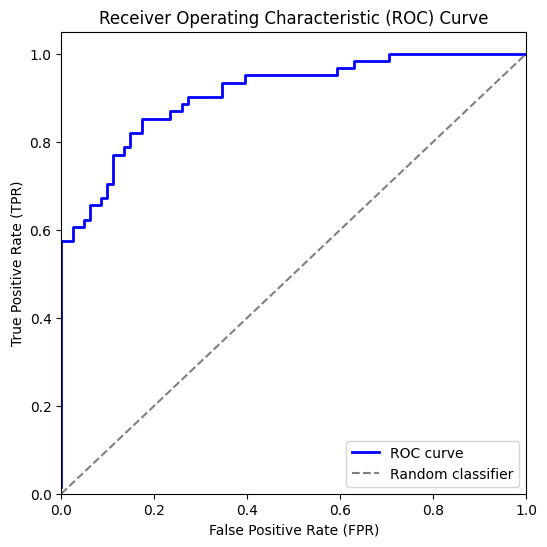

In [33]:
# import pyspark
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, expr
import matplotlib.pyplot as plt

results = results.withColumn("probability_array", vector_to_array(col("probability")))
results = results.withColumn("probability_positive", col("probability_array")[1])

# Calcula los puntos de la curva ROC utilizando la métrica integrada de PySpark
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import StringIndexer

# Evaluar el modelo y obtener los puntos de la curva ROC
evaluator = BinaryClassificationEvaluator(labelCol="Survived", rawPredictionCol="probability_positive", metricName="areaUnderROC")
roc_curve = evaluator.evaluate(results, {evaluator.metricName: "areaUnderROC"})

# Extraer los datos de la curva ROC (fpr, tpr)
roc = results.select("probability_positive", "Survived").rdd.map(lambda row: (float(row['probability_positive']), float(row['Survived']))).collect()

# Ordenar los puntos por la probabilidad predicha
roc = sorted(roc, key=lambda x: x[0], reverse=True)

# Inicializamos listas para TPR y FPR
fpr = []
tpr = []
thresholds = []
positives = sum([1 for i in roc if i[1] == 1.0])
negatives = sum([1 for i in roc if i[1] == 0.0])

tp = 0
fp = 0

# Calcular TPR y FPR en cada umbral
for prob, label in roc:
    if label == 1.0:
        tp += 1
    else:
        fp += 1
    tpr.append(tp / positives if positives > 0 else 0)
    fpr.append(fp / negatives if negatives > 0 else 0)
    thresholds.append(prob)

# Graficar la curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()



##### Como interpretar el gráfico ROC

* El mejor método posible de predicción se situaría en un punto en la esquina superior izquierda, o coordenada (0,1) del espacio ROC, representando un 100% de sensibilidad (ningún falso negativo) y un 100% también de especificidad (ningún falso positivo). A este punto (0,1) también se le llama una clasificación perfecta. Por el contrario, una clasificación totalmente aleatoria (o adivinación aleatoria) daría un punto a lo largo de la línea diagonal, que se llama también línea de no-discriminación, desde el extremo inferior izquierdo hasta la esquina superior derecha (independientemente de los tipos de base positivas y negativas). Un ejemplo típico de adivinación aleatoria sería decidir a partir de los resultados de lanzar una moneda al aire, a medida que el tamaño de la muestra aumenta, el punto de un clasificador aleatorio de ROC se desplazará hacia la posición (0.5, 0.5).
* Cada resultado de predicción o instancia de la matriz de confusión representa un punto en el espacio ROC.

-- https://es.wikipedia.org/wiki/Curva_ROC
-- https://en.wikipedia.org/wiki/Precision_and_recall

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql import functions as F

# Calcula la precisión del modelo
evaluator = MulticlassClassificationEvaluator(labelCol='Survived', predictionCol='prediction', metricName='accuracy')
accuracy = evaluator.evaluate(results)
print("Precisión del Modelo = %g" % (accuracy))

# Construir la matriz de confusión manualmente
# Filtra las etiquetas reales (Survived) y las predicciones (prediction)
confusion_matrix = results.groupBy('Survived', 'prediction').count()

# Mostrar la matriz de confusión
print("Matriz de confusión:")
confusion_matrix.show()

# Extraer los valores de la matriz de confusión
TP = confusion_matrix.filter((confusion_matrix.Survived == 1) & (confusion_matrix.prediction == 1)).select('count').collect()[0][0]
TN = confusion_matrix.filter((confusion_matrix.Survived == 0) & (confusion_matrix.prediction == 0)).select('count').collect()[0][0]
FP = confusion_matrix.filter((confusion_matrix.Survived == 0) & (confusion_matrix.prediction == 1)).select('count').collect()[0][0]
FN = confusion_matrix.filter((confusion_matrix.Survived == 1) & (confusion_matrix.prediction == 0)).select('count').collect()[0][0]

# Calcular otras métricas
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Mostrar las métricas
print(f"Precisión (Precision): {precision}")
print(f"Sensibilidad (Recall): {recall}")
print(f"Puntuación F1 (F1 Score): {f1_score}")
print(f"Verdaderos Positivos (TP): {TP}")
print(f"Verdaderos Negativos (TN): {TN}")
print(f"Falsos Positivos (FP): {FP}")
print(f"Falsos Negativos (FN): {FN}")


Precisión del Modelo = 0.816901
Matriz de confusión:
+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       1|       0.0|   18|
|       0|       0.0|   73|
|       1|       1.0|   43|
|       0|       1.0|    8|
+--------+----------+-----+

